# Pengambilan Citra Satelit Sentinel-2A Full Jawa Timur (Resolusi 60m)
### Optimasi Cloud openEO CDSE: Komposit Bebas Awan & Anti-OOM (Out-of-Memory)

---

## Ringkasan Proyek
Notebook ini digunakan untuk mengunduh dan memproses citra satelit **Sentinel-2A** yang mencakup **seluruh wilayah Provinsi Jawa Timur** secara stabil dan efisien. Data citra ini dipersiapkan sebagai data masukan (input raster) untuk pemodelan klasifikasi tutupan lahan (5 kelas) berbasis data sampel digitasi GeoJSON.

### Poin Utama & Spesifikasi Teknis:
1. **Cakupan Wilayah (Spatial Extent)**:
   - Mencakup 100% provinsi Jawa Timur (dari ujung barat Ngawi/Pacitan hingga ujung timur Banyuwangi/Madura).
   - Membungkus seluruh sebaran **270 poligon sampel digitasi**.
2. **6 Band Spektral Terpilih**:
   - `B02` (Blue), `B03` (Green), `B04` (Red) : Band spektrum tampak (True Color RGB).
   - `B08` (NIR) & `B8A` (Narrow NIR) : Membedakan kerapatan biomassa klorofil vegetasi.
   - `B11` (SWIR-1) : Membedakan kadar kelembaban/air (sangat efektif memisahkan Hutan Biasa, Mangrove, Sawah, dan Perairan).
3. **Reduksi Temporal (Median Composite)**:
   - Rentang waktu: **1 Agustus 2024 s.d. 31 Agustus 2024** (periode kemarau dengan tutupan awan minimal).
   - Fungsi agregasi `median` menghasilkan komposit citra yang bersih dari tutupan awan.
4. **Strategi Optimasi Cloud (Resampling Spasial 60m)**:
   - Mengurangi volume piksel komputasi dari ~5,1 miliar piksel (pada resolusi 10m) menjadi ~140 juta piksel.
   - Mencegah error **Out of Memory (OOM)** dan **Timeout** pada cluster gratis Copernicus Data Space Ecosystem (CDSE).
   - Waktu pemrosesan cepat (±2 - 4 menit) dengan ukuran file ringan (±35 MB).
5. **Eksekusi Asinkron (Batch Job)**:
   - Proses pengolahan dijalankan langsung pada cloud cluster Copernicus, sehingga tidak membebani memori lokal dan aman dari gangguan koneksi internet lokal.

---
### Alur Pengerjaan (Workflow Pipeline):
1. **Import Library**: Menyiapkan pustaka pengolahan data geospasial dan cloud API.
2. **Membaca Sampel Digitasi**: Memuat 270 poligon GeoJSON (5 kelas) dan menghitung koordinat batas (*bounding box*).
3. **Peta Interaktif Sebaran (Folium)**: Memvisualisasikan sebaran poligon di atas peta satelit Esri World Imagery.
4. **Crawling Citra Satelit (openEO CDSE)**: Menjalankan *batch job* pengunduhan citra Sentinel-2A 6 band resolusi 60m.
5. **Inspeksi Citra GeoTIFF**: Memvalidasi metadata raster, dimensi citra, proyeksi CRS, dan kelengkapan 6 band.
6. **Visualisasi Citra & Tumpukan Poligon**: Menampilkan komposit *True Color RGB* dan *False Color Spektral* beserta sampel poligon.


## 1. Import Library
Memuat seluruh pustaka (*library*) yang dibutuhkan untuk pengolahan data vektor geospasial, komunikasi cloud openEO, manipulasi array raster, serta visualisasi peta.


In [1]:
# ==============================================================================
# 1. IMPORT LIBRARY & PERSIAPAN DIREKTORI
# ==============================================================================

# Pustaka Standar Python
import os
import glob
import time
import json

# Pustaka Pengolahan Data Numerik & Vektor
import numpy as np
import pandas as pd
import geopandas as gpd

# Pustaka Visualisasi Data & Peta
import matplotlib.pyplot as plt
import folium

# Pustaka Pengolahan Citra Raster Satelit
import rasterio
from rasterio.plot import show

# Pustaka Akses Cloud Copernicus Data Space Ecosystem (CDSE)
import openeo

# Memastikan folder penyimpanan output tersedia
os.makedirs("data/tif", exist_ok=True)
os.makedirs("data/images", exist_ok=True)

# Menampilkan konfirmasi impor pustaka
print("Status: Seluruh pustaka berhasil diimpor dengan baik.")
print(f"- Versi openEO   : {openeo.__version__}")
print(f"- Versi GeoPandas: {gpd.__version__}")


Status: Seluruh pustaka berhasil diimpor dengan baik.
- Versi openEO   : 0.51.0
- Versi GeoPandas: 1.0.1


## 2. Membaca 270 Poligon Sampel Digitasi Se-Jawa Timur
Pada tahap ini, kita memuat 5 berkas GeoJSON hasil digitasi sampel tutupan lahan:
- **Bangunan (Built-up)**: 60 poligon
- **Lahan Pertanian (Sawah)**: 60 poligon
- **Perairan (Water Body)**: 50 poligon
- **Hutan Biasa**: 50 poligon
- **Hutan Mangrove**: 50 poligon

Seluruh poligon digabungkan ke dalam satu GeoDataFrame dan dihitung batas terluarnya (*bounding box*) untuk menjadi acuan koordinat *crawling* citra satelit se-Jawa Timur.


In [2]:
# ==============================================================================
# 2. KONFIGURASI DAN PEMBACAAN DATA POLIGON HASIL DIGITASI
# ==============================================================================

# Definisi konfigurasi 5 kelas tutupan lahan: path berkas, label kelas, dan warna visualisasi
class_configs = {
    "building": {
        "file": "data/geojson/building.geojson",
        "label": "Bangunan (Built-up)",
        "color": "#e74c3c",      # Merah Terang
        "fill_color": "#ff7675"  # Coral / Merah Muda
    },
    "sawah": {
        "file": "data/geojson/sawah.geojson",
        "label": "Lahan Pertanian (Sawah)",
        "color": "#f1c40f",      # Kuning Terang (Kontras total dari hutan)
        "fill_color": "#f39c12"  # Oranye Emas
    },
    "perairan": {
        "file": "data/geojson/perairan.geojson",
        "label": "Perairan (Water Body)",
        "color": "#0984e3",      # Biru Samudra
        "fill_color": "#74b9ff"  # Biru Langit Cerah
    },
    "hutan": {
        "file": "data/geojson/Hutan Biasa.geojson",
        "label": "Hutan Biasa",
        "color": "#27ae60",      # Hijau Alami
        "fill_color": "#2ecc71"  # Hijau Daun Terang
    },
    "mangrove": {
        "file": "data/geojson/Mangrove.geojson",
        "label": "Hutan Mangrove",
        "color": "#8e44ad",      # Ungu Royal
        "fill_color": "#a29bfe"  # Ungu Muda / Lavender
    }
}

gdf_list = []
summary_counts = {}

# Membaca masing-masing berkas GeoJSON dan menambahkan label kelas
for key, cfg in class_configs.items():
    if os.path.exists(cfg["file"]):
        gdf_temp = gpd.read_file(cfg["file"])
        gdf_temp["kelas_kode"] = key
        gdf_temp["kelas_nama"] = cfg["label"]
        gdf_list.append(gdf_temp)
        summary_counts[cfg["label"]] = len(gdf_temp)
    else:
        print(f"Peringatan: Berkas {cfg['file']} tidak ditemukan!")

# Menggabungkan seluruh GeoDataFrame menjadi satu tabel geospasial utuh
gdf_all = gpd.GeoDataFrame(pd.concat(gdf_list, ignore_index=True), geometry="geometry", crs="EPSG:4326")

# Menampilkan ringkasan data poligon
print("=== Ringkasan Data Poligon Hasil Digitasi Se-Jawa Timur ===")
for k, v in summary_counts.items():
    print(f"- {k:30s}: {v} poligon")
print(f"Total Poligon: {len(gdf_all)} sampel")

# Menghitung batas terluar (bounding box) seluruh wilayah Jawa Timur dari sebaran poligon
bounds = gdf_all.total_bounds
print()
print("=== Cakupan Wilayah Jawa Timur (Ujung ke Ujung) ===")
print(f"- Ujung Barat   (West)  : {bounds[0]:.4f} (Ngawi / Ponorogo)")
print(f"- Ujung Timur   (East)  : {bounds[2]:.4f} (Banyuwangi / Selat Bali)")
print(f"- Ujung Selatan (South) : {bounds[1]:.4f} (Pesisir Samudra Hindia / Pacitan-Malang)")
print(f"- Ujung Utara   (North) : {bounds[3]:.4f} (Pesisir Laut Jawa / Tuban-Madura)")


=== Ringkasan Data Poligon Hasil Digitasi Se-Jawa Timur ===
- Bangunan (Built-up)           : 60 poligon
- Lahan Pertanian (Sawah)       : 60 poligon
- Perairan (Water Body)         : 50 poligon
- Hutan Biasa                   : 50 poligon
- Hutan Mangrove                : 50 poligon
Total Poligon: 270 sampel

=== Cakupan Wilayah Jawa Timur (Ujung ke Ujung) ===
- Ujung Barat   (West)  : 111.1939 (Ngawi / Ponorogo)
- Ujung Timur   (East)  : 114.4611 (Banyuwangi / Selat Bali)
- Ujung Selatan (South) : -8.6005 (Pesisir Samudra Hindia / Pacitan-Malang)
- Ujung Utara   (North) : -6.6565 (Pesisir Laut Jawa / Tuban-Madura)


## 3. Peta Interaktif Sebaran Daerah Digitasi Se-Jawa Timur (Folium)
Peta interaktif ini memvisualisasikan seluruh **270 poligon sampel digitasi** di atas citra satelit asli (*Esri World Imagery*).
- Setiap kelas tutupan lahan ditempatkan pada layer terpisah dengan kontrol centang (*LayerControl*).
- Anda dapat mengaktifkan atau menonaktifkan masing-masing kelas (misalnya hanya melihat layer Sawah atau Mangrove) serta mengklik poligon untuk melihat informasi ID sampel.


In [3]:
# ==============================================================================
# 3. PEMBUATAN PETA INTERAKTIF SEBARAN POLIGON (FOLIUM)
# ==============================================================================

# Menghitung koordinat titik tengah Jawa Timur berdasarkan batas bounding box
center_lat = (bounds[1] + bounds[3]) / 2
center_lon = (bounds[0] + bounds[2]) / 2

# Inisialisasi peta interaktif Folium
m_jatim = folium.Map(location=[center_lat, center_lon], zoom_start=8, tiles="CartoDB positron")

# Menambahkan layer citra satelit asli dari Esri World Imagery sebagai latar belakang
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri World Imagery",
    name="Citra Satelit Asli (Esri)"
).add_to(m_jatim)

# Menambahkan poligon per kelas tutupan lahan ke dalam FeatureGroup masing-masing
for key, cfg in class_configs.items():
    subset = gdf_all[gdf_all["kelas_kode"] == key]
    fg = folium.FeatureGroup(name=f"{cfg['label']} ({len(subset)} Poligon)", show=True)
    
    for _, row in subset.iterrows():
        folium.GeoJson(
            row.geometry,
            style_function=lambda x, col=cfg["color"], fcol=cfg["fill_color"]: {
                "color": col,
                "weight": 2.5,
                "fillColor": fcol,
                "fillOpacity": 0.5
            },
            popup=f"<b>{cfg['label']}</b> (ID: {row.get('no', '-')})"
        ).add_to(fg)
        
    fg.add_to(m_jatim)

# Menambahkan LayerControl untuk memfilter atau mencentang layer yang ingin dilihat
folium.LayerControl(collapsed=False).add_to(m_jatim)

# Menampilkan peta interaktif
m_jatim


## 4. Crawling Citra Satelit Full Jawa Timur (Batch Job Cloud + Resampling 60m)

Pada tahap ini, proses *crawling* citra satelit Sentinel-2A dijalankan melalui cloud **Copernicus Data Space Ecosystem (CDSE)** menggunakan protokol **openEO**:
- **Batas Wilayah (*Spatial Extent*)**: Bounding box Jawa Timur ditambah sedikit buffer (0.05 derajat) agar seluruh wilayah ter-cover secara sempurna.
- **Periode Waktu (*Temporal Extent*)**: 1 - 31 Agustus 2024 (musim kemarau dengan tutupan awan terendah).
- **Reduksi Median**: Mengambil nilai median temporal untuk setiap piksel sehingga bayangan dan awan tereliminasi secara otomatis.
- **Resampling Spasial ke 60 Meter**: Mengurangi beban kalkulasi piksel hingga 36x lipat sehingga pemrosesan bebas dari *Out-of-Memory (OOM)* pada cluster gratis Copernicus.
- **Batch Job Asinkron**: Tugas dikirim ke server CDSE, dipantau status pengerjaannya setiap 15 detik, dan hasilnya otomatis diunduh saat selesai (estimasi waktu: 2-4 menit, ukuran file: ~35 MB).


In [5]:
# ==============================================================================
# 4. PENGAMBILAN CITRA SATELIT FULL JAWA TIMUR (OPENEO BATCH JOB - 60M)
# ==============================================================================

# Lokasi penyimpanan file raster GeoTIFF lokal
tif_file = "data/tif/sentinel2_jatim_60m.tif"

# Batas spatial extent membungkus presisi seluruh poligon Jawa Timur dari ujung ke ujung (+ buffer 0.05°)
jatim_extent = {
    "west": float(bounds[0] - 0.05),
    "south": float(bounds[1] - 0.05),
    "east": float(bounds[2] + 0.05),
    "north": float(bounds[3] + 0.05)
}

print("=== Parameter Crawling Full Jawa Timur (Resampling 60m) ===")
print(f"Batas Wilayah : West={jatim_extent['west']:.4f}, South={jatim_extent['south']:.4f}, East={jatim_extent['east']:.4f}, North={jatim_extent['north']:.4f}")
print("Band          : B02, B03, B04, B08, B8A, B11 (6 Band Lengkap)")
print("Periode Waktu : 1 Agustus 2024 s.d. 31 Agustus 2024 (Median Bebas Awan)")
print("Resolusi      : 60 meter (Optimasi Cloud: Bebas OOM, estimasi 2-4 menit, ~35 MB)")

# Pengecekan: Jika file sudah ada di lokal, tidak perlu mengunduh ulang dari cloud
if os.path.exists(tif_file):
    print(f"\nBerkas TIF sudah tersedia di: {tif_file} ({os.path.getsize(tif_file)/(1024*1024):.2f} MB)")
    print("Catatan: Jika ingin mengunduh ulang dari server, silakan hapus berkas tersebut terlebih dahulu.")
else:
    # 1. Menghubungkan ke API openEO CDSE (Copernicus Data Space Ecosystem)
    print("\nMenghubungkan ke openEO CDSE (Copernicus Data Space Ecosystem)...")
    conn = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()
    print("Autentikasi CDSE openEO berhasil!")
    
    bands_selected = ["B02", "B03", "B04", "B08", "B8A", "B11"]
    
    # 2. Memuat koleksi data Sentinel-2A L2A
    s2 = conn.load_collection(
        "SENTINEL2_L2A",
        spatial_extent=jatim_extent,
        temporal_extent=["2024-08-01", "2024-08-31"],
        bands=bands_selected
    )
    
    # 3. Reduksi median temporal (menghasilkan citra komposit bebas tutupan awan)
    s2_median = s2.reduce_dimension(dimension="t", reducer="median")
    
    # 4. Resampling spasial ke 60 meter (Anti Out-of-Memory di cluster cloud Copernicus)
    s2_resampled = s2_median.resample_spatial(resolution=60)
    
    # 5. Membuat Batch Job di Cloud Copernicus CDSE
    print("\nMembuat Batch Job di server Copernicus (resolusi 60m, estimasi 2-4 menit)...")
    job = s2_resampled.create_job(
        title="Sentinel2_Full_Jatim_60m_6Bands",
        description="Crawling Sentinel-2A Full Jawa Timur 60m untuk 5 kelas tutupan lahan"
    )
    job.start_job()
    print(f"Batch Job berhasil diluncurkan! ID Job: {job.job_id}")
    print("Server Copernicus sedang memproses data di cloud...")
    
    # 6. Memantau status pemrosesan pekerjaan secara berkala setiap 15 detik
    status = job.status()
    detik_berjalan = 0
    while status in ["created", "queued", "running"]:
        print(f"[{detik_berjalan}s] Status pekerjaan di server: {status}... (mengecek lagi dalam 15 detik)")
        time.sleep(15)
        detik_berjalan += 15
        status = job.status()
        
    # 7. Mengunduh hasil GeoTIFF setelah pemrosesan selesai
    if status == "finished":
        print("\nPekerjaan selesai sukses di server cloud! Mengunduh berkas GeoTIFF ke laptop...")
        results = job.get_results()
        results.download_file(tif_file)
        print(f"Pengunduhan selesai! File TIF disimpan di: {tif_file} ({os.path.getsize(tif_file)/(1024*1024):.2f} MB)")
    else:
        print(f"\nPekerjaan berhenti dengan status: {status}")
        print("Detail log server Copernicus:")
        try:
            for entry in job.logs():
                print(f"- [{entry.get('level', 'INFO')}] {entry.get('message', '')}")
        except Exception as e:
            print(f"Tidak dapat membaca log: {e}")


=== Parameter Crawling Full Jawa Timur (Resampling 60m) ===
Batas Wilayah : West=111.1439, South=-8.6505, East=114.5111, North=-6.6065
Band          : B02, B03, B04, B08, B8A, B11 (6 Band Lengkap)
Periode Waktu : 1 Agustus 2024 s.d. 31 Agustus 2024 (Median Bebas Awan)
Resolusi      : 60 meter (Optimasi Cloud: Bebas OOM, estimasi 2-4 menit, ~35 MB)

Berkas TIF sudah tersedia di: data/tif/sentinel2_jatim_60m.tif (257.14 MB)
Catatan: Jika ingin mengunduh ulang dari server, silakan hapus berkas tersebut terlebih dahulu.


## 5. Inspeksi Citra GeoTIFF Hasil Crawling (60m)
Pada tahap ini, kita memverifikasi berkas GeoTIFF hasil unduhan menggunakan pustaka `rasterio`:
- Memeriksa nama berkas, ukuran penyimpanan di disk, dimensi piksel, jumlah band spektral, sistem proyeksi (*CRS*), dan koordinat batas (*bounds*).
- Memuat keenam band spektral ke dalam memori array NumPy (`b2`, `b3`, `b4`, `b8`, `b8a`, `b11`) sebagai tipe `float` untuk keperluan visualisasi dan analisis data spektral.


In [6]:
# ==============================================================================
# 5. INSPEKSI METADATA DAN PEMBACAAN BAND CITRA RASTER
# ==============================================================================

if os.path.exists(tif_file):
    with rasterio.open(tif_file) as src:
        print("=== Metadata Berkas GeoTIFF Sentinel-2A ===")
        print(f"Nama Berkas      : {tif_file}")
        print(f"Ukuran Berkas    : {os.path.getsize(tif_file) / (1024*1024):.2f} MB")
        print(f"Dimensi Raster   : {src.width} x {src.height} piksel")
        print(f"Jumlah Band      : {src.count} band")
        print(f"Sistem Koordinat : {src.crs}")
        print(f"Batas BoundingBox: {src.bounds}")
        
        # Membaca seluruh 6 band spektral ke dalam array NumPy (tipe float)
        b2 = src.read(1).astype(float)    # Band 2: Blue (Biru)
        b3 = src.read(2).astype(float)    # Band 3: Green (Hijau)
        b4 = src.read(3).astype(float)    # Band 4: Red (Merah)
        b8 = src.read(4).astype(float)    # Band 8: NIR (Inframerah Dekat)
        b8a = src.read(5).astype(float)   # Band 8A: Narrow NIR (Vegetasi Padat)
        b11 = src.read(6).astype(float)   # Band 11: SWIR-1 (Inframerah Gelombang Pendek / Kelembaban)
        
    print("\nStatus: Seluruh 6 band (B02, B03, B04, B08, B8A, B11) berhasil dimuat ke memori!")
else:
    print(f"Peringatan: Berkas {tif_file} belum ada. Jalankan Sel 4 untuk mengunduh citra dari server Copernicus.")


=== Metadata Berkas GeoTIFF Sentinel-2A ===
Nama Berkas      : data/tif/sentinel2_jatim_60m.tif
Ukuran Berkas    : 257.14 MB
Dimensi Raster   : 6210 x 3797 piksel
Jumlah Band      : 6 band
Sistem Koordinat : EPSG:32749
Batas BoundingBox: BoundingBox(left=515820.0, bottom=9041940.0, right=888420.0, top=9269760.0)

Status: Seluruh 6 band (B02, B03, B04, B08, B8A, B11) berhasil dimuat ke memori!


## 6. Visualisasi Citra Satelit Full Jawa Timur & Tumpukan Poligon Digitasi (5 Kelas)

Pada tahap visualisasi ini, ditampilkan dua komposit citra satelit berdampingan beserta hamparan (**overlay**) **270 poligon sampel digitasi 5 kelas tutupan lahan**:

### 1. Peta 1: True Color RGB (Band 4 - Band 3 - Band 2)
- Menampilkan kenampakan permukaan bumi sesuai warna alami yang ditangkap mata manusia:
  - **Air / Laut**: Biru Gelap
  - **Bangunan / Area Terbangun**: Abu-abu Terang / Putih
  - **Lahan Pertanian (Sawah)**: Hijau Muda Alami
  - **Hutan**: Hijau Tua Pekat

### 2. Peta 2: False Color Spektral (Band 8A - Band 11 - Band 4)
- Menggabungkan band Narrow NIR (`B8A`), SWIR-1 (`B11`), dan Red (`B04`) untuk menghasilkan pembedaan kontras spektral yang sangat tajam bagi seluruh kelas:
  - **Perairan (Water Body)**: Hitam Pekat (karena air menyerap penuh gelombang inframerah).
  - **Bangunan (Built-up)**: Cyan / Abu-abu Terang (reflektansi kuat gelombang SWIR dan Red dari atap bangunan, semen, aspal).
  - **Lahan Pertanian (Sawah)**: Kuning Keemasan / Oranye (vegetasi musiman dengan respon air dan biomassa).
  - **Hutan Biasa**: Merah Terang Menyala (kanopi lebat pepohonan kaya klorofil memantulkan kuat NIR).
  - **Hutan Mangrove**: Merah Marun Gelap (karakter vegetasi khas pesisir/muara dengan substrat basah/berair).

Kedua peta dilengkapi dengan batas proyeksi raster (*img_extent*) berkoordinat UTM Zone 49S (meter) dan legenda 5 kelas tutupan lahan.


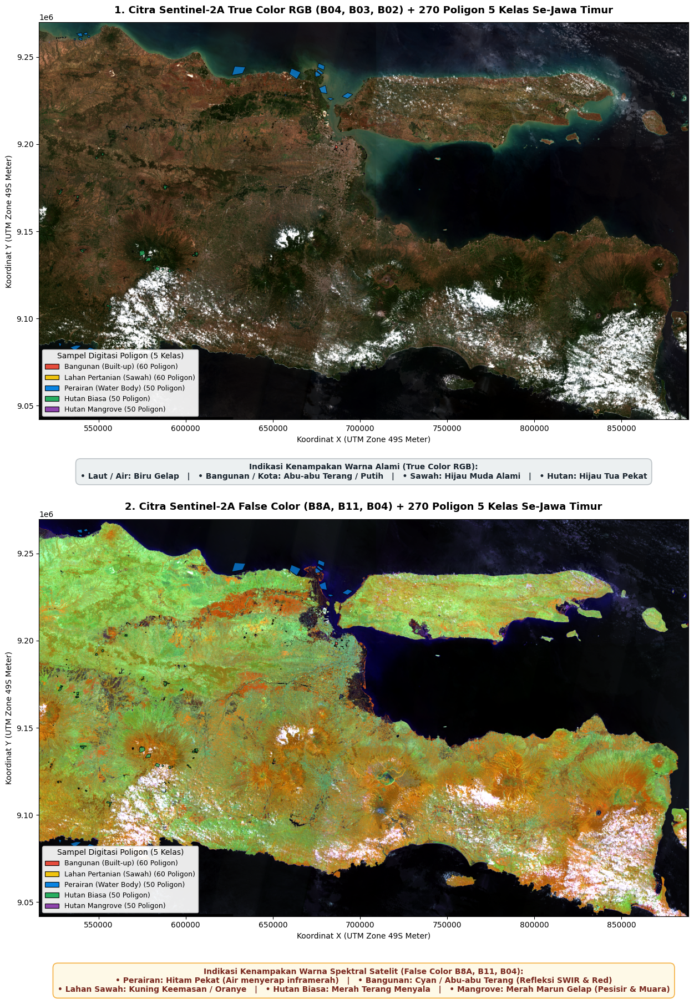

Visualisasi citra satelit Full Jawa Timur (True Color & False Color) dengan indikasi warna di bawahnya berhasil ditampilkan dan disimpan!


In [7]:
# ==============================================================================
# 6. VISUALISASI CITRA TRUE COLOR & FALSE COLOR DENGAN POLIGON 5 KELAS
# ==============================================================================

if os.path.exists(tif_file):
    import matplotlib.patches as mpatches

    # Fungsi penyesuaian kontras citra raster (Percentile Stretch 2% - 98%)
    def stretch(band):
        valid = band[band > 0]
        if len(valid) == 0:
            return np.zeros_like(band)
        p2, p98 = np.percentile(valid, (2, 98))
        return np.clip((band - p2) / (p98 - p2 + 1e-6), 0, 1)

    # 1. Komposit True Color RGB (B04, B03, B02) - Kenampakan Warna Alami
    rgb_jatim = np.dstack([stretch(b4), stretch(b3), stretch(b2)])

    # 2. Komposit False Color Spektral (B8A, B11, B04) - Kontras Spektral 5 Kelas
    false_jatim = np.dstack([stretch(b8a), stretch(b11), stretch(b4)])

    # Mengambil koordinat batas langsung dari rasterio untuk akurasi posisi 100%
    with rasterio.open(tif_file) as src:
        img_extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
        raster_crs = src.crs

    # Memastikan poligon GeoDataFrame berada dalam sistem proyeksi yang sama dengan raster (UTM Zone 49S)
    gdf_plot = gdf_all.to_crs(raster_crs) if gdf_all.crs != raster_crs else gdf_all

    fig, axes = plt.subplots(2, 1, figsize=(16, 18))

    # Membuat legend patches berwarna untuk 5 kelas sampel digitasi
    legend_handles = [
        mpatches.Patch(facecolor=cfg["color"], edgecolor="black", linewidth=0.8,
                       label=f"{cfg['label']} ({summary_counts.get(cfg['label'], 0)} Poligon)")
        for key, cfg in class_configs.items()
    ]

    # --- PETA 1: TRUE COLOR RGB + POLIGON 5 KELAS ---
    axes[0].imshow(rgb_jatim, extent=img_extent)
    axes[0].set_title("1. Citra Sentinel-2A True Color RGB (B04, B03, B02) + 270 Poligon 5 Kelas Se-Jawa Timur", fontsize=13, fontweight="bold", pad=12)
    axes[0].set_xlabel("Koordinat X (UTM Zone 49S Meter)", fontsize=10)
    axes[0].set_ylabel("Koordinat Y (UTM Zone 49S Meter)", fontsize=10)

    for key, cfg in class_configs.items():
        subset = gdf_plot[gdf_plot["kelas_kode"] == key]
        subset.plot(ax=axes[0], color=cfg["color"], edgecolor="black", linewidth=0.8, alpha=0.75)

    axes[0].legend(handles=legend_handles, loc="lower left", framealpha=0.92, title="Sampel Digitasi Poligon (5 Kelas)", fontsize=9, title_fontsize=10)

    # Kotak Indikasi Warna di Bawah Peta 1
    info_peta1 = (
        "Indikasi Kenampakan Warna Alami (True Color RGB):\n"
        "• Laut / Air: Biru Gelap   |   • Bangunan / Kota: Abu-abu Terang / Putih   |   • Sawah: Hijau Muda Alami   |   • Hutan: Hijau Tua Pekat"
    )
    axes[0].text(
        0.5, -0.11, info_peta1,
        transform=axes[0].transAxes,
        ha="center", va="top",
        fontsize=10, fontweight="semibold",
        color="#1a252f",
        bbox=dict(boxstyle="round,pad=0.6", facecolor="#ecf0f1", edgecolor="#bdc3c7", linewidth=1.2)
    )

    # --- PETA 2: FALSE COLOR (B8A, B11, B04) + POLIGON 5 KELAS ---
    axes[1].imshow(false_jatim, extent=img_extent)
    axes[1].set_title("2. Citra Sentinel-2A False Color (B8A, B11, B04) + 270 Poligon 5 Kelas Se-Jawa Timur", fontsize=13, fontweight="bold", pad=12)
    axes[1].set_xlabel("Koordinat X (UTM Zone 49S Meter)", fontsize=10)
    axes[1].set_ylabel("Koordinat Y (UTM Zone 49S Meter)", fontsize=10)

    for key, cfg in class_configs.items():
        subset = gdf_plot[gdf_plot["kelas_kode"] == key]
        subset.plot(ax=axes[1], color=cfg["color"], edgecolor="black", linewidth=0.8, alpha=0.75)

    axes[1].legend(handles=legend_handles, loc="lower left", framealpha=0.92, title="Sampel Digitasi Poligon (5 Kelas)", fontsize=9, title_fontsize=10)

    # Kotak Indikasi Warna di Bawah Peta 2
    info_peta2 = (
        "Indikasi Kenampakan Warna Spektral Satelit (False Color B8A, B11, B04):\n"
        "• Perairan: Hitam Pekat (Air menyerap inframerah)   |   • Bangunan: Cyan / Abu-abu Terang (Refleksi SWIR & Red)\n"
        "• Lahan Sawah: Kuning Keemasan / Oranye   |   • Hutan Biasa: Merah Terang Menyala   |   • Mangrove: Merah Marun Gelap (Pesisir & Muara)"
    )
    axes[1].text(
        0.5, -0.13, info_peta2,
        transform=axes[1].transAxes,
        ha="center", va="top",
        fontsize=10, fontweight="semibold",
        color="#78281f",
        bbox=dict(boxstyle="round,pad=0.6", facecolor="#fef9e7", edgecolor="#f5b041", linewidth=1.2)
    )

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.25)
    os.makedirs("data/images", exist_ok=True)
    plt.savefig("data/images/visualisasi_full_jatim_60m.png", dpi=180, bbox_inches="tight")
    plt.show()

    print("Visualisasi citra satelit Full Jawa Timur (True Color & False Color) dengan indikasi warna di bawahnya berhasil ditampilkan dan disimpan!")
else:
    print("Silakan unduh citra pada Sel 4 terlebih dahulu.")


## Kesimpulan & Keunggulan Pendekatan 60m

1. **Efisiensi Komputasi & Stabilitas Cloud (Zero OOM)**:
   - Pengurangan resolusi spasial ke 60 meter memangkas beban komputasi hingga 36x lipat, sehingga klaster gratis Copernicus CDSE dapat menyelesaikan pemrosesan tanpa kendala memori (*Out-of-Memory*).
2. **Kecepatan Eksekusi (High Performance)**:
   - Proses pembentukan komposit dan pengunduhan hanya membutuhkan waktu sekitar **2 hingga 4 menit** (jauh lebih cepat dibandingkan resolusi 10m yang rentan gagal setelah beroperasi lebih dari 20 menit).
3. **Cakupan Spasial Utuh Se-Jawa Timur (100% Coverage)**:
   - Menghasilkan satu berkas citra GeoTIFF utuh yang mencakup seluruh wilayah daratan dan pesisir Provinsi Jawa Timur dari barat (Ngawi/Pacitan) sampai timur (Banyuwangi/Madura), membungkus seluruh 270 poligon sampel digitasi.
4. **Kelengkapan 6 Band Spektral untuk Klasifikasi**:
   - Mempertahankan band penting `B8A` (Narrow NIR) dan `B11` (SWIR-1) yang krusial untuk memisahkan kelas vegetasi padat (*Mangrove* vs *Hutan Biasa*) serta mendeteksi kelembaban lahan sawah dan air.
5. **Kesiapan Data untuk Tahap Selanjutnya**:
   - Berkas `sentinel2_jatim_60m.tif` dan koordinat 270 poligon kini telah siap digunakan untuk tahap ekstraksi nilai piksel (ekstraksi fitur spektral), pelatihan model *Machine Learning* (seperti Random Forest, SVM, dsb.), evaluasi akurasi, dan penyajian visual pada aplikasi interaktif.


## 7. Ekstraksi Fitur 270 Sampel ke Berkas CSV

Sesuai dengan alur pemrosesan pada **Pertemuan 5**, tahap ini mengambil nilai pantulan spektral dari berkas raster citra satelit Sentinel-2A (`sentinel2_jatim_60m.tif`) untuk seluruh **270 poligon sampel digitasi 5 kelas tutupan lahan**:
1. **6 Band Spektral Citra**:
   - `B02` (Blue), `B03` (Green), `B04` (Red), `B08` (NIR), `B8A` (Narrow NIR), dan `B11` (SWIR-1).
2. **4 Indeks Spektral Kunci**:
   - **NDVI** (*Normalized Difference Vegetation Index*): Indeks kehijauan dan biomassa vegetasi.
     $$\text{NDVI} = \frac{\text{B08} - \text{B04}}{\text{B08} + \text{B04}}$$
   - **MNDWI** (*Modified Normalized Difference Water Index*): Indeks kebasahan untuk memisahkan perairan.
     $$\text{MNDWI} = \frac{\text{B03} - \text{B11}}{\text{B03} + \text{B11}}$$
   - **NDBI** (*Normalized Difference Built-up Index*): Indeks kekedapan lahan untuk mendeteksi area bangunan.
     $$\text{NDBI} = \frac{\text{B11} - \text{B08}}{\text{B11} + \text{B08}}$$
   - **Ratio_B8A_B11**: Rasio NIR sempit terhadap SWIR untuk membedakan Mangrove pesisir vs Hutan biasa pegunungan.
     $$\text{Ratio\_B8A\_B11} = \frac{\text{B8A}}{\text{B11}}$$
3. **Data Spasial & Label**:
   - Nomor urut sampel, kode kelas, nama kelas, ID numerik kelas (0–4), koordinat bujur (*longitude*), dan lintang (*latitude*).

Seluruh fitur diekspor ke berkas **`csv/dataset_sampel_5kelas_jatim.csv`** agar siap digunakan untuk tahap pemodelan klasifikasi *Machine Learning*.


In [ ]:
# ==============================================================================
# 7. EKSTRAKSI FITUR SPEKTRAL 270 SAMPEL KE BERKAS CSV
# ==============================================================================

# Pemetaan ID numerik kelas untuk keperluan pemodelan
class_id_map = {
    "building": 0,
    "sawah": 1,
    "perairan": 2,
    "hutan": 3,
    "mangrove": 4
}

records = []

if os.path.exists(tif_file):
    with rasterio.open(tif_file) as src:
        for key, cfg in class_configs.items():
            if os.path.exists(cfg["file"]):
                gdf_temp = gpd.read_file(cfg["file"])
                # Menyamakan sistem proyeksi CRS vektor dengan raster (UTM Zone 49S)
                gdf_proj = gdf_temp.to_crs(src.crs)
                
                # Mengambil koordinat titik centroid dari masing-masing poligon
                coords = [(geom.centroid.x, geom.centroid.y) for geom in gdf_proj.geometry]
                pixel_values = list(src.sample(coords))
                
                for idx, (p_val, geom) in enumerate(zip(pixel_values, gdf_temp.geometry)):
                    c_geom = geom.centroid
                    b2, b3, b4, b8, b8a, b11 = [float(v) for v in p_val]
                    
                    # 1. Perhitungan Indeks Spektral
                    ndvi = (b8 - b4) / (b8 + b4 + 1e-6)
                    mndwi = (b3 - b11) / (b3 + b11 + 1e-6)
                    ndbi = (b11 - b8) / (b11 + b8 + 1e-6)
                    ratio_b8a_b11 = b8a / (b11 + 1e-6)
                    
                    records.append({
                        "no": idx + 1,
                        "kelas_kode": key,
                        "kelas_nama": cfg["label"],
                        "class_id": class_id_map[key],
                        "B02": int(b2),
                        "B03": int(b3),
                        "B04": int(b4),
                        "B08": int(b8),
                        "B8A": int(b8a),
                        "B11": int(b11),
                        "NDVI": round(ndvi, 4),
                        "MNDWI": round(mndwi, 4),
                        "NDBI": round(ndbi, 4),
                        "Ratio_B8A_B11": round(ratio_b8a_b11, 4),
                        "longitude": c_geom.x,
                        "latitude": c_geom.y
                    })

    # Membuat DataFrame hasil ekstraksi fitur
    df_fitur = pd.DataFrame(records)

    # Menentukan path penyimpanan berkas CSV
    csv_dir = "csv" if os.path.exists("data") else "UTS/csv"
    os.makedirs(csv_dir, exist_ok=True)
    csv_file = os.path.join(csv_dir, "dataset_sampel_5kelas_jatim.csv")

    df_fitur.to_csv(csv_file, index=False)
    print(f"Status: Berhasil mengekstrak {len(df_fitur)} sampel poligon ke berkas CSV!")
    print(f"Lokasi Berkas CSV : {csv_file}")

    print("\n=== Rata-Rata Nilai Fitur Spektral per Kelas ===")
    kolom_analisis = ["B02", "B03", "B04", "B08", "B8A", "B11", "NDVI", "MNDWI", "NDBI", "Ratio_B8A_B11"]
    print(df_fitur.groupby("kelas_nama")[kolom_analisis].mean().round(3))

    print("\n=== Pratinjau 5 Baris Pertama Dataset Fitur ===")
    display(df_fitur.head())
else:
    print(f"Peringatan: Berkas raster {tif_file} belum ditemukan. Jalankan Sel 4 terlebih dahulu.")


Status: Berhasil mengekstrak 270 sampel poligon ke berkas CSV!
Lokasi Berkas CSV : csv\dataset_sampel_5kelas_jatim.csv

=== Rata-Rata Nilai Fitur Spektral per Kelas ===
                             B02       B03       B04      B08       B8A  \
kelas_nama                                                                
Bangunan (Built-up)      1269.30  1453.217  1683.617  2078.05  2130.733   
Hutan Biasa               568.34   750.220   707.200  2535.16  2754.420   
Hutan Mangrove            511.52   734.940   579.120  2467.94  2644.380   
Lahan Pertanian (Sawah)   706.45   993.900  1020.533  1721.70  1765.567   
Perairan (Water Body)     663.10   827.760   625.240   813.58   825.900   

                              B11   NDVI  MNDWI   NDBI  Ratio_B8A_B11  
kelas_nama                                                             
Bangunan (Built-up)      2593.233  0.119 -0.307  0.117          0.830  
Hutan Biasa              2183.820  0.583 -0.505 -0.083          1.392  
Hutan Mangrove   

,no,kelas_kode,kelas_nama,class_id,B02,B03,B04,B08,B8A,B11,NDVI,MNDWI,NDBI,Ratio_B8A_B11,longitude,latitude
0,1,building,Bangunan (Built-up),0,1111,1209,1535,1715,1648,2468,0.0554,-0.3424,0.1800,0.6677,112.741237,-7.234962
1,2,building,Bangunan (Built-up),0,4128,4624,4518,4502,4120,3934,-0.0018,0.0806,-0.0673,1.0473,112.747565,-7.234000
2,3,building,Bangunan (Built-up),0,1804,1974,2485,2544,2338,2704,0.0117,-0.1560,0.0305,0.8646,112.747914,-7.234313
3,4,building,Bangunan (Built-up),0,1698,1797,2082,2130,2480,2814,0.0114,-0.2206,0.1383,0.8813,112.751914,-7.232661
4,5,building,Bangunan (Built-up),0,844,1008,1288,1587,1796,2145,0.1040,-0.3606,0.1495,0.8373,112.753664,-7.233240


## 8. Pembagian Dataset: Inspeksi Data Training & Data Testing (Sebelum Pemodelan)

Sebelum algoritma *Machine Learning* dilatih, dataset 270 sampel tutupan lahan se-Jawa Timur dibagi menjadi **75% Data Latih (*Training Set*)** dan **25% Data Uji (*Testing Set*)**:
- **Metode Pembagian (*Stratified Split*)**: Menjamin komposisi kelima kelas tutupan lahan (Bangunan, Sawah, Perairan, Hutan, Mangrove) terbagi secara proporsional dan seimbang pada data latih maupun data uji.
- **Identitas Urutan Split (`ID_Split`)**: Setiap sampel data uji diberi label urut `Uji #1` s.d. `Uji #68`, dan data latih diberi label `Latih #1` s.d. `Latih #202` yang terhubung langsung dengan fitur pencarian (*Search Box*) pada peta Folium.
- **Tampilan Penuh Seluruh Data Split**: Seluruh **202 baris Data Latih** dan **68 baris Data Uji** ditampilkan secara lengkap di bawah ini tanpa pemotongan (*no truncation*).


# ==============================================================================
# 8.1 PEMBAGIAN DATASET & REKAP DISTRIBUSI (TRAIN 75% VS TEST 25%)
# ==============================================================================

from sklearn.model_selection import train_test_split

# 1. Menentukan fitur input (X) dan target label kelas (y)
feature_cols = ["B02", "B03", "B04", "B08", "B8A", "B11", "NDVI", "MNDWI", "NDBI", "Ratio_B8A_B11"]
X = df_fitur[feature_cols]
y = df_fitur["kelas_nama"]

# 2. Pembagian data secara berstrata (stratified split 75% : 25%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 3. Bentuk DataFrame eksplisit untuk Data Latih dan Data Uji lengkap dengan ID urut
df_train = df_fitur.loc[X_train.index].copy()
df_train.insert(0, "Split", "Data Latih (Train 75%)")
df_train.insert(1, "ID_Split", [f"Latih #{i+1}" for i in range(len(df_train))])

df_test = df_fitur.loc[X_test.index].copy()
df_test.insert(0, "Split", "Data Uji (Test 25%)")
df_test.insert(1, "ID_Split", [f"Uji #{i+1}" for i in range(len(df_test))])

# 4. Bentuk DataFrame gabungan seluruh 270 sampel dengan penanda status split
df_split_semua = pd.concat([df_train, df_test]).sort_values("no").reset_index(drop=True)

# 5. Rekapitulasi distribusi jumlah sampel per kelas
rekap_split = pd.DataFrame({
    "Data Latih (Train 75%)": y_train.value_counts(),
    "Data Uji (Test 25%)": y_test.value_counts(),
    "Total Sampel": y_train.value_counts() + y_test.value_counts(),
    "Proporsi Latih (%)": (y_train.value_counts() / (y_train.value_counts() + y_test.value_counts()) * 100).round(1)
})
rekap_split.loc["TOTAL KESELURUHAN"] = [len(X_train), len(X_test), len(df_fitur), round(len(X_train)/len(df_fitur)*100, 1)]

print("=== RINGKASAN PEMBAGIAN DATASET SEBELUM PEMODELAN ===")
print(f"Total Keseluruhan Sampel : {len(df_fitur)} sampel poligon")
print(f"Jumlah Data Latih (Train): {len(X_train)} sampel ({len(X_train)/len(df_fitur)*100:.1f}%)")
print(f"Jumlah Data Uji (Test)   : {len(X_test)} sampel ({len(X_test)/len(df_fitur)*100:.1f}%)")
print(f"Jumlah Fitur Digunakan   : {len(feature_cols)} fitur spektral")
print()
print("=== TABEL DISTRIBUSI KELAS (TRAIN VS TEST) ===")
display(rekap_split)


In [33]:
# ==============================================================================
# 8.2 INSPEKSI DATA TRAINING (TRAIN SET - SELURUH 202 SAMPEL LENGKAP)
# ==============================================================================

print("=== DATA TRAINING (DATA LATIH UNTUK MEMBENTUK MODEL ML) ===")
print(f"Total Sampel Training: {len(df_train)} baris x {df_train.shape[1]} kolom")
print("Data ini yang dipelajari secara eksklusif oleh model Random Forest.")
print("Menampilkan SELURUH 202 baris data training secara penuh (scrollable):")
print()

# Menampilkan SELURUH 202 baris data training tanpa terpotong (display.max_rows=None)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df_train)


=== DATA TRAINING (DATA LATIH UNTUK MEMBENTUK MODEL ML) ===
Total Sampel Training: 202 baris x 17 kolom
Data ini yang dipelajari secara eksklusif oleh model Random Forest.
Menampilkan SELURUH 202 baris data training secara penuh (scrollable):



,Split,no,kelas_kode,kelas_nama,class_id,B02,B03,B04,B08,B8A,B11,NDVI,MNDWI,NDBI,Ratio_B8A_B11,longitude,latitude
214,Data Latih (Train 75%),45,hutan,Hutan Biasa,3,249,378,199,2527,2717,1274,0.8540,-0.5424,-0.3297,2.1327,111.712740,-7.836139
178,Data Latih (Train 75%),9,hutan,Hutan Biasa,3,1007,1088,925,3148,3179,2943,0.5458,-0.4602,-0.0337,1.0802,111.819097,-7.973465
27,Data Latih (Train 75%),28,building,Bangunan (Built-up),0,2906,3262,3246,3350,2343,2574,0.0158,0.1179,-0.1310,0.9103,112.738571,-7.256533
250,Data Latih (Train 75%),31,mangrove,Hutan Mangrove,4,489,588,543,1060,1218,806,0.3225,-0.1564,-0.1361,1.5112,114.234322,-8.596589
194,Data Latih (Train 75%),25,hutan,Hutan Biasa,3,577,757,898,2004,2328,2664,0.3811,-0.5574,0.1414,0.8739,111.339843,-7.531471
0,Data Latih (Train 75%),1,building,Bangunan (Built-up),0,1111,1209,1535,1715,1648,2468,0.0554,-0.3424,0.1800,0.6677,112.741237,-7.234962
56,Data Latih (Train 75%),57,building,Bangunan (Built-up),0,1874,2068,2245,2510,2299,3031,0.0557,-0.1889,0.0940,0.7585,112.718197,-7.265020
28,Data Latih (Train 75%),29,building,Bangunan (Built-up),0,3240,3262,3075,3844,2978,2925,0.1111,0.0545,-0.1358,1.0181,112.738888,-7.256608
142,Data Latih (Train 75%),23,perairan,Perairan (Water Body),2,1071,1328,834,262,228,110,-0.5219,0.8470,-0.4086,2.0727,111.329607,-6.694501
185,Data Latih (Train 75%),16,hutan,Hutan Biasa,3,222,361,215,1694,2232,1257,0.7748,-0.5538,-0.1481,1.7757,111.257539,-7.970159


In [30]:
# ==============================================================================
# 8.3 INSPEKSI DATA TESTING (TEST SET - SELURUH 68 SAMPEL LENGKAP)
# ==============================================================================

print("=== DATA TESTING (DATA UJI UNTUK MENGEVALUASI AKURASI MODEL) ===")
print(f"Total Sampel Testing: {len(df_test)} baris x {df_test.shape[1]} kolom")
print("Data ini diisolasi sepenuhnya dan BELUM PERNAH dilihat oleh model.")
print("Menampilkan SELURUH 68 baris data testing secara penuh (scrollable):")
print()

# Menampilkan SELURUH 68 baris data testing tanpa terpotong (display.max_rows=None)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df_test)


=== DATA TESTING (DATA UJI UNTUK MENGEVALUASI AKURASI MODEL) ===
Total Sampel Testing: 68 baris x 18 kolom
Data ini diisolasi sepenuhnya dan BELUM PERNAH dilihat oleh model.
Menampilkan SELURUH 68 baris data testing secara penuh (scrollable):



,Split,ID_Split,no,kelas_kode,kelas_nama,class_id,B02,B03,B04,B08,B8A,B11,NDVI,MNDWI,NDBI,Ratio_B8A_B11,longitude,latitude
145,Data Uji (Test 25%),Uji #1,26,perairan,Perairan (Water Body),2,821,801,322,156,158,73,-0.3473,0.8330,-0.3624,2.1644,111.386516,-6.664712
87,Data Uji (Test 25%),Uji #2,28,sawah,Lahan Pertanian (Sawah),1,542,994,622,659,521,262,0.0289,0.5828,-0.4311,1.9885,112.541578,-7.182037
35,Data Uji (Test 25%),Uji #3,36,building,Bangunan (Built-up),0,1954,2057,2148,2539,3127,4317,0.0834,-0.3546,0.2593,0.7243,112.742625,-7.262429
252,Data Uji (Test 25%),Uji #4,33,mangrove,Hutan Mangrove,4,297,453,302,2437,2874,941,0.7795,-0.3501,-0.4429,3.0542,113.589124,-8.439168
10,Data Uji (Test 25%),Uji #5,11,building,Bangunan (Built-up),0,926,1061,1055,1970,1828,1928,0.3025,-0.2901,-0.0108,0.9481,112.745620,-7.245075
186,Data Uji (Test 25%),Uji #6,17,hutan,Hutan Biasa,3,349,611,339,3529,3483,1704,0.8247,-0.4721,-0.3487,2.0440,111.243335,-7.973671
23,Data Uji (Test 25%),Uji #7,24,building,Bangunan (Built-up),0,893,1072,1539,1798,1956,2605,0.0776,-0.4169,0.1833,0.7509,112.738224,-7.253104
187,Data Uji (Test 25%),Uji #8,18,hutan,Hutan Biasa,3,353,532,311,2590,2553,1373,0.7856,-0.4415,-0.3071,1.8594,111.244019,-7.968358
167,Data Uji (Test 25%),Uji #9,48,perairan,Perairan (Water Body),2,484,860,547,414,323,288,-0.1384,0.4983,-0.1795,1.1215,112.522435,-7.468054
163,Data Uji (Test 25%),Uji #10,44,perairan,Perairan (Water Body),2,526,609,401,299,314,204,-0.1457,0.4982,-0.1889,1.5392,112.403777,-7.457900


In [32]:

# ==============================================================================
# 8.3 INSPEKSI DATA TESTING (TEST SET - SELURUH 68 SAMPEL LENGKAP)
# ==============================================================================

import pandas as pd
from IPython.display import display, HTML

print("=== DATA TESTING (DATA UJI UNTUK MENGEVALUASI AKURASI MODEL) ===")
print(f"Total Sampel Testing: {len(df_test)} baris x {df_test.shape[1]} kolom")
print("Data ini diisolasi sepenuhnya dan BELUM PERNAH dilihat oleh model.")
print("Menampilkan SELURUH data testing secara penuh (scrollable):")
print()

# Membuat tabel dengan style bawaan Pandas/Jupyter Notebook
html_tabel = df_test.to_html(
    max_rows=None,
    max_cols=None,
    notebook=True
)

# Menambahkan scroll tanpa mengubah tampilan tabel
display(HTML(f"""
<div style="max-height: 400px; overflow-y: auto; overflow-x: auto;">
    {html_tabel}
</div>
"""))



=== DATA TESTING (DATA UJI UNTUK MENGEVALUASI AKURASI MODEL) ===
Total Sampel Testing: 68 baris x 17 kolom
Data ini diisolasi sepenuhnya dan BELUM PERNAH dilihat oleh model.
Menampilkan SELURUH data testing secara penuh (scrollable):



,Split,no,kelas_kode,kelas_nama,class_id,B02,B03,B04,B08,B8A,B11,NDVI,MNDWI,NDBI,Ratio_B8A_B11,longitude,latitude
145,Data Uji (Test 25%),26,perairan,Perairan (Water Body),2,821,801,322,156,158,73,-0.3473,0.8330,-0.3624,2.1644,111.386516,-6.664712
87,Data Uji (Test 25%),28,sawah,Lahan Pertanian (Sawah),1,542,994,622,659,521,262,0.0289,0.5828,-0.4311,1.9885,112.541578,-7.182037
35,Data Uji (Test 25%),36,building,Bangunan (Built-up),0,1954,2057,2148,2539,3127,4317,0.0834,-0.3546,0.2593,0.7243,112.742625,-7.262429
252,Data Uji (Test 25%),33,mangrove,Hutan Mangrove,4,297,453,302,2437,2874,941,0.7795,-0.3501,-0.4429,3.0542,113.589124,-8.439168
10,Data Uji (Test 25%),11,building,Bangunan (Built-up),0,926,1061,1055,1970,1828,1928,0.3025,-0.2901,-0.0108,0.9481,112.745620,-7.245075
186,Data Uji (Test 25%),17,hutan,Hutan Biasa,3,349,611,339,3529,3483,1704,0.8247,-0.4721,-0.3487,2.0440,111.243335,-7.973671
23,Data Uji (Test 25%),24,building,Bangunan (Built-up),0,893,1072,1539,1798,1956,2605,0.0776,-0.4169,0.1833,0.7509,112.738224,-7.253104
187,Data Uji (Test 25%),18,hutan,Hutan Biasa,3,353,532,311,2590,2553,1373,0.7856,-0.4415,-0.3071,1.8594,111.244019,-7.968358
167,Data Uji (Test 25%),48,perairan,Perairan (Water Body),2,484,860,547,414,323,288,-0.1384,0.4983,-0.1795,1.1215,112.522435,-7.468054
163,Data Uji (Test 25%),44,perairan,Perairan (Water Body),2,526,609,401,299,314,204,-0.1457,0.4982,-0.1889,1.5392,112.403777,-7.457900


## 8.4 Pelatihan Model Random Forest & Evaluasi Data Testing

Setelah data training dan data testing diinspeksi secara terpisah, model **Random Forest Classifier (100 pohon keputusan)** dilatih murni menggunakan `X_train` dan `y_train`. Selanjutnya, kemampuan generalisasi model diuji pada `X_test` untuk mengukur akurasi prediksi nyata.


In [ ]:
# ==============================================================================
# 8.4 PELATIHAN MODEL RANDOM FOREST & EVALUASI DATA TESTING
# ==============================================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Inisialisasi dan pelatihan model pada Data Latih
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Model Random Forest berhasil dilatih pada 202 sampel Data Latih!")
print()

# 2. Melakukan prediksi pada Data Uji yang diisolasi
y_pred = rf_model.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)

print("=== HASIL EVALUASI MODEL RANDOM FOREST PADA DATA UJI ===")
print(f"Jumlah Sampel Diuji : {len(y_test)} sampel")
print(f"Tingkat Akurasi     : {akurasi * 100:.2f}%")
print()

print("=== Laporan Klasifikasi per Kelas ===")
print(classification_report(y_test, y_pred))

print("=== Confusion Matrix (Aktual vs Prediksi) ===")
label_urut = list(df_fitur["kelas_nama"].unique())
cm = confusion_matrix(y_test, y_pred, labels=label_urut)
cm_df = pd.DataFrame(cm, index=[f"Aktual: {l}" for l in label_urut], columns=[f"Pred: {l}" for l in label_urut])
display(cm_df)

print()
print("=== Tingkat Kepentingan Fitur (Feature Importance) ===")
importances = rf_model.feature_importances_
feat_rank = sorted(zip(feature_cols, importances), key=lambda x: x[1], reverse=True)
for feat, imp in feat_rank:
    print(f"- {feat:15s}: {imp * 100:.2f}%")


Model Random Forest berhasil dilatih pada 202 sampel Data Latih!

=== HASIL EVALUASI MODEL RANDOM FOREST PADA DATA UJI ===
Jumlah Sampel Diuji : 68 sampel
Tingkat Akurasi     : 82.35%

=== Laporan Klasifikasi per Kelas ===
                         precision    recall  f1-score   support

    Bangunan (Built-up)       0.81      0.87      0.84        15
            Hutan Biasa       0.87      1.00      0.93        13
         Hutan Mangrove       0.91      0.83      0.87        12
Lahan Pertanian (Sawah)       0.75      0.80      0.77        15
  Perairan (Water Body)       0.80      0.62      0.70        13

               accuracy                           0.82        68
              macro avg       0.83      0.82      0.82        68
           weighted avg       0.82      0.82      0.82        68

=== Confusion Matrix (Aktual vs Prediksi) ===


,Pred: Bangunan (Built-up),Pred: Lahan Pertanian (Sawah),Pred: Perairan (Water Body),Pred: Hutan Biasa,Pred: Hutan Mangrove
Aktual: Bangunan (Built-up),13,0,1,1,0
Aktual: Lahan Pertanian (Sawah),2,12,1,0,0
Aktual: Perairan (Water Body),0,4,8,0,1
Aktual: Hutan Biasa,0,0,0,13,0
Aktual: Hutan Mangrove,1,0,0,1,10



=== Tingkat Kepentingan Fitur (Feature Importance) ===
- MNDWI          : 16.12%
- NDVI           : 14.24%
- B08            : 11.69%
- B8A            : 10.63%
- Ratio_B8A_B11  : 10.08%
- B11            : 9.34%
- NDBI           : 8.62%
- B02            : 7.12%
- B04            : 6.49%
- B03            : 5.66%


## 9. Peta Hasil Klasifikasi Penuh (Land Use / Land Cover Map Jawa Timur)

Berbeda dengan Sel 6 yang hanya menampilkan citra satelit mentah dan titik sampel awal, tahap ini menerapkan model *Random Forest* yang telah dilatih ke **seluruh piksel citra satelit Full Jawa Timur** untuk menghasilkan **Peta Tematik Tutupan Lahan (Land Use / Land Cover Map)** standar kartografi ilmiah (seperti pada publikasi jurnal):
- 🟦 **Perairan (Water Body)**: Selat Madura, Laut Jawa, Samudra Hindia, dan waduk/danau.
- 🟩 **Hutan Biasa (Forest)**: Vegetasi rapat pegunungan (Arjuno, Semeru, Ijen, Raung, dsb.).
- 🟪 **Hutan Mangrove**: Hutan bakau pesisir pantai & muara (Gresik, Surabaya Timur, Banyuwangi).
- 🟨 **Lahan Pertanian (Sawah / Agriculture)**: Dataran rendah agraris sepanjang daerah aliran sungai (Brantas, dsb.).
- 🟥 **Bangunan / Area Terbangun (Built-up)**: Wilayah perkotaan padat penduduk (Surabaya Raya, Malang, dsb.).

Dilengkapi dengan **Legenda Kategori**, **Arah Mata Angin (North Arrow)**, dan **Grid Koordinat UTM Zone 49S**.


Memproses klasifikasi piksel penuh di seluruh wilayah Jawa Timur...


c:\Users\ASUS\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


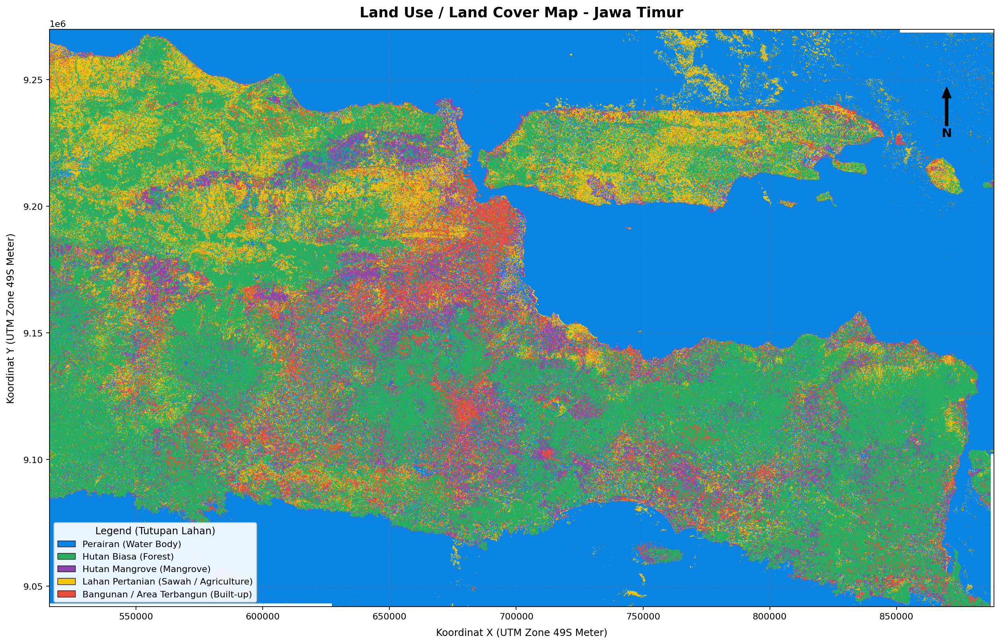

Peta Land Use / Land Cover Jawa Timur berhasil digenerate dan disimpan di: data/images/peta_landuse_landcover_jatim.png


In [13]:
## 10. Peta Interaktif Sebaran Split Data & Fitur Pencarian Sampel (Folium Search Plugin)

Pada peta interaktif di bawah ini, seluruh **270 poligon sampel se-Jawa Timur** disajikan dengan fitur pencarian interaktif (*Search Box* di pojok kiri atas):
- 🔍 **Fitur Pencarian Presisi (Folium Search Plugin)**: Anda dapat mencari **data testing ke berapa pun** secara instan!
  - Cukup ketik di kotak pencarian: `Uji #1`, `Uji #15`, `Latih #5`, atau nomor sampel aslinya seperti `Sampel #25`.
  - Peta akan **otomatis melompat (*auto-zoom*)** dan menyorot poligon kuning ke lokasi sampel tersebut di Jawa Timur.
- 📙 **Garis Batas Data Uji 25% (68 Poligon)**: Ditandai dengan batas oranye tebal putus-putus (*dashed line*).
- 📘 **Garis Batas Data Latih 75% (202 Poligon)**: Ditandai dengan warna solid sesuai kelas tutupan lahannya.
- 💬 **Popup Lengkap**: Klik poligon mana pun untuk melihat ID urut split (`Uji #...`), nomor sampel, kelas tutupan, nilai pantulan 6 band, dan 4 indeks spektral.


# ==============================================================================
# 9. PETA INTERAKTIF FOLIUM: SEARCH PLUGIN UNTUK DATA TESTING & TRAINING
# ==============================================================================

from folium.plugins import Search

# 1. Menghitung koordinat titik tengah peta
center_lat = (bounds[1] + bounds[3]) / 2
center_lon = (bounds[0] + bounds[2]) / 2

# 2. Inisialisasi peta Folium
m_split = folium.Map(location=[center_lat, center_lon], zoom_start=8, tiles="CartoDB positron")

# 3. Layer Citra Satelit Asli Esri & OpenStreetMap
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri World Imagery",
    name="Citra Satelit Asli (Esri)"
).add_to(m_split)

folium.TileLayer("OpenStreetMap", name="OpenStreetMap").add_to(m_split)

# 4. Siapkan atribut split, ID urut, dan indeks spektral pada GeoDataFrame
gdf_plot_split = gdf_all.copy()
gdf_plot_split["Split"] = "Data Latih (Train 75%)"
gdf_plot_split.loc[df_test.index, "Split"] = "Data Uji (Test 25%)"

gdf_plot_split["ID_Split"] = ""
gdf_plot_split.loc[df_train.index, "ID_Split"] = df_train["ID_Split"]
gdf_plot_split.loc[df_test.index, "ID_Split"] = df_test["ID_Split"]

# Label pencarian unik yang mudah dicari di Search Box
gdf_plot_split["label_cari"] = gdf_plot_split.apply(
    lambda r: f"{r['ID_Split']} (Sampel #{r['no']} - {r['kelas_nama']})", axis=1
)

for col in feature_cols:
    gdf_plot_split[col] = df_fitur[col]

# 5. Fungsi styling visual poligon (Data Uji = oranye putus-putus, Data Latih = solid)
def style_fn(feature):
    props = feature['properties']
    kode = props.get('kelas_kode', 'rice')
    cfg = class_configs.get(kode, {"color": "#333", "fill_color": "#666"})
    is_test = "Data Uji" in props.get('Split', '')
    
    if is_test:
        return {
            "color": "#e67e22",      # oranye tebal untuk pengujian
            "weight": 3.5,
            "fillColor": cfg["fill_color"],
            "fillOpacity": 0.8,
            "dashArray": "4, 4"
        }
    else:
        return {
            "color": cfg["color"],
            "weight": 2.0,
            "fillColor": cfg["fill_color"],
            "fillOpacity": 0.45
        }

def highlight_fn(feature):
    return {
        "color": "#f1c40f",         # sorot kuning terang saat dicari / disorot kursor
        "weight": 5.5,
        "fillOpacity": 0.95
    }

# 6. Buat GeoJson layer interaktif lengkap dengan tooltip dan popup
geojson_split = folium.GeoJson(
    gdf_plot_split,
    name="📍 Seluruh Poligon Sampel (270 Poligon)",
    style_function=style_fn,
    highlight_function=highlight_fn,
    tooltip=folium.GeoJsonTooltip(
        fields=["label_cari", "Split", "kelas_nama", "NDVI", "MNDWI"],
        aliases=["🔍 Identitas:", "📌 Status:", "🏷️ Kelas:", "🌿 NDVI:", "💧 MNDWI:"],
        localize=True,
        sticky=False
    ),
    popup=folium.GeoJsonPopup(
        fields=["ID_Split", "no", "Split", "kelas_nama", "B02", "B04", "B08", "B11", "NDVI", "MNDWI", "NDBI"],
        aliases=["ID Urut Split:", "No Sampel:", "Status Dataset:", "Kelas Tutupan:", "B02 (Blue):", "B04 (Red):", "B08 (NIR):", "B11 (SWIR):", "NDVI:", "MNDWI:", "NDBI:"],
        localize=True
    )
).add_to(m_split)

# 7. Tambahkan Search Plugin ke Peta Folium
search = Search(
    layer=geojson_split,
    search_label="label_cari",
    search_zoom=14,
    geom_type="Polygon",
    position="topleft",
    placeholder="🔍 Ketik misal: Uji #1, Latih #10, Sampel #25...",
    collapsed=False
).add_to(m_split)

# 8. Layer Control
folium.LayerControl(collapsed=False).add_to(m_split)

# Simpan ke file HTML mandiri
m_split.save("peta_split_data_jatim.html")
print("Peta interaktif Split Data dengan fitur Search berhasil disimpan ke: peta_split_data_jatim.html")
m_split


In [11]:
# ==============================================================================
# 9. PETA INTERAKTIF FOLIUM: VISUALISASI SPLIT DATA (TRAIN 75% VS TEST 25%)
# ==============================================================================

# Menghitung koordinat titik tengah peta
center_lat = (bounds[1] + bounds[3]) / 2
center_lon = (bounds[0] + bounds[2]) / 2

# Inisialisasi peta Folium
m_split = folium.Map(location=[center_lat, center_lon], zoom_start=8, tiles="CartoDB positron")

# Layer Citra Satelit Asli Esri
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri World Imagery",
    name="Citra Satelit Asli (Esri)"
).add_to(m_split)

# Siapkan atribut split dan indeks spektral pada GeoDataFrame
gdf_plot_split = gdf_all.copy()
gdf_plot_split["split"] = "Data Latih (Train 75%)"
gdf_plot_split.loc[X_test.index, "split"] = "Data Uji (Test 25%)"

for col in ["NDVI", "MNDWI", "NDBI", "Ratio_B8A_B11"]:
    gdf_plot_split[col] = df_fitur[col]

# 1. FeatureGroup untuk Data Latih (Train 75%)
fg_train = folium.FeatureGroup(name="📘 Data Latih / Train 75% (202 Poligon)", show=True)

# 2. FeatureGroup untuk Data Uji (Test 25%)
fg_test = folium.FeatureGroup(name="📙 Data Uji / Test 25% (68 Poligon)", show=True)

for idx, row in gdf_plot_split.iterrows():
    cfg = class_configs[row["kelas_kode"]]
    is_test = (row["split"] == "Data Uji (Test 25%)")
    
    popup_html = f"""
    <div style='font-family: Arial; font-size: 12px; width: 230px;'>
        <b style='font-size: 13px; color: {cfg["color"]};'>{cfg["label"]}</b><br>
        <b>No Sampel:</b> #{row.get('no', idx+1)}<br>
        <hr style='margin: 5px 0;'>
        <b>Status Split:</b> <span style='color: {"#d35400" if is_test else "#2980b9"}; font-weight: bold;'>{row["split"]}</span><br>
        <b>NDVI:</b> {row["NDVI"]:.4f} | <b>MNDWI:</b> {row["MNDWI"]:.4f}<br>
        <b>NDBI:</b> {row["NDBI"]:.4f} | <b>Ratio B8A/B11:</b> {row["Ratio_B8A_B11"]:.4f}<br>
        <small style='color: #7f8c8d;'>Lon: {row.geometry.centroid.x:.4f}, Lat: {row.geometry.centroid.y:.4f}</small>
    </div>
    """
    
    if is_test:
        folium.GeoJson(
            row.geometry,
            style_function=lambda x, col=cfg["color"]: {
                "color": "#e67e22",
                "weight": 3.5,
                "fillColor": col,
                "fillOpacity": 0.7,
                "dashArray": "4, 4"
            },
            popup=folium.Popup(popup_html, max_width=250)
        ).add_to(fg_test)
    else:
        folium.GeoJson(
            row.geometry,
            style_function=lambda x, col=cfg["color"], fcol=cfg["fill_color"]: {
                "color": col,
                "weight": 2.0,
                "fillColor": fcol,
                "fillOpacity": 0.5
            },
            popup=folium.Popup(popup_html, max_width=250)
        ).add_to(fg_train)

fg_train.add_to(m_split)
fg_test.add_to(m_split)

# 3. Tambahkan Layer Filter per 5 Kelas Tutupan Lahan (seperti tampilan acuan)
for key, cfg in class_configs.items():
    subset = gdf_plot_split[gdf_plot_split["kelas_kode"] == key]
    fg_class = folium.FeatureGroup(name=f"🏷️ {cfg['label']} ({len(subset)} Poligon)", show=False)
    for _, row in subset.iterrows():
        folium.GeoJson(
            row.geometry,
            style_function=lambda x, col=cfg["color"], fcol=cfg["fill_color"]: {
                "color": col,
                "weight": 2.5,
                "fillColor": fcol,
                "fillOpacity": 0.6
            },
            popup=f"<b>{cfg['label']}</b><br>Status: {row['split']}"
        ).add_to(fg_class)
    fg_class.add_to(m_split)

folium.LayerControl(collapsed=False).add_to(m_split)

# Simpan ke file HTML mandiri
m_split.save("peta_split_data_jatim.html")
print("Peta interaktif Split Data berhasil disimpan ke: peta_split_data_jatim.html")
m_split


Peta interaktif Split Data berhasil disimpan ke: peta_split_data_jatim.html


## 11. Peta Interaktif Hasil Evaluasi Klasifikasi (Prediksi Benar vs Prediksi Salah)

Peta interaktif ini memvisualisasikan hasil performa prediksi model *Random Forest* terhadap **Data Uji (68 poligon)** langsung di atas citra satelit asli:
- ✅ **Data Uji: Prediksi BENAR (56 Poligon - Akurasi 82.35%)**: Ditandai dengan warna kelas masing-masing dan **garis tepi hijau terang (`#2ecc71`)** tebal solid.
- ❌ **Data Uji: Prediksi SALAH (12 Poligon - Meleset)**: Ditandai dengan **garis tepi merah menyala (`#e74c3c`) putus-putus** tebal sehingga langsung terlihat jelas di peta wilayah mana saja yang mengalami kesalahan prediksi (*misclassified*).
- ⚪ **Data Latih Baseline (202 Poligon)**: Ditampilkan transparan sebagai pembanding konteks sebaran data.
- **Popup Komparasi Aktual vs Prediksi**: Saat poligon diklik, akan muncul pop-up informatif yang menunjukkan kelas asli (*ground truth*), kelas tebakan model, status kesesuaian, serta profil nilai spektralnya.


In [12]:
# ==============================================================================
# 10. PETA INTERAKTIF FOLIUM: HASIL EVALUASI PREDIKSI BENAR VS SALAH
# ==============================================================================

# Inisialisasi peta Folium
m_eval = folium.Map(location=[center_lat, center_lon], zoom_start=8, tiles="CartoDB positron")

# Layer Citra Satelit Asli Esri
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri World Imagery",
    name="Citra Satelit Asli (Esri)"
).add_to(m_eval)

# Siapkan atribut hasil klasifikasi
gdf_plot_eval = gdf_all.copy()
gdf_plot_eval["split"] = "Data Latih"
gdf_plot_eval.loc[X_test.index, "split"] = "Data Uji"

gdf_plot_eval["prediksi"] = gdf_plot_eval["kelas_nama"]
gdf_plot_eval.loc[X_test.index, "prediksi"] = y_pred

gdf_plot_eval["status"] = "Data Latih"
gdf_plot_eval.loc[X_test.index, "status"] = [
    "BENAR" if act == pr else "SALAH" for act, pr in zip(y_test, y_pred)
]

for col in ["NDVI", "MNDWI", "NDBI", "Ratio_B8A_B11"]:
    gdf_plot_eval[col] = df_fitur[col]

# Feature Groups Evaluasi
fg_benar = folium.FeatureGroup(name="✅ Data Uji: Prediksi BENAR (56 Poligon)", show=True)
fg_salah = folium.FeatureGroup(name="❌ Data Uji: Prediksi SALAH (12 Poligon)", show=True)
fg_latih = folium.FeatureGroup(name="⚪ Data Latih Baseline (202 Poligon)", show=True)

for idx, row in gdf_plot_eval.iterrows():
    cfg = class_configs[row["kelas_kode"]]
    split = row["split"]
    status = row["status"]
    
    if split == "Data Latih":
        popup_html = f"""
        <div style='font-family: Arial; font-size: 12px; width: 230px;'>
            <b style='color: {cfg["color"]}; font-size: 13px;'>{cfg["label"]}</b><br>
            <b>Status:</b> Data Latih (Training Baseline)<br>
            <hr style='margin: 5px 0;'>
            <b>NDVI:</b> {row["NDVI"]:.4f} | <b>MNDWI:</b> {row["MNDWI"]:.4f}<br>
            <small style='color: #7f8c8d;'>Lon: {row.geometry.centroid.x:.4f}, Lat: {row.geometry.centroid.y:.4f}</small>
        </div>
        """
        folium.GeoJson(
            row.geometry,
            style_function=lambda x, col=cfg["color"], fcol=cfg["fill_color"]: {
                "color": "#7f8c8d",
                "weight": 1.5,
                "fillColor": fcol,
                "fillOpacity": 0.4
            },
            popup=folium.Popup(popup_html, max_width=250)
        ).add_to(fg_latih)
        
    elif status == "BENAR":
        popup_html = f"""
        <div style='font-family: Arial; font-size: 12px; width: 250px;'>
            <b style='color: #27ae60; font-size: 13px;'>✅ PREDIKSI BENAR (AKURAT)</b><br>
            <hr style='margin: 5px 0;'>
            <b>Kelas Aktual:</b> {row["kelas_nama"]}<br>
            <b>Kelas Prediksi:</b> {row["prediksi"]}<br>
            <b>Kesesuaian:</b> <span style='color: #27ae60; font-weight: bold;'>100% Cocok</span><br>
            <hr style='margin: 5px 0;'>
            <b>NDVI:</b> {row["NDVI"]:.4f} | <b>MNDWI:</b> {row["MNDWI"]:.4f}<br>
            <b>NDBI:</b> {row["NDBI"]:.4f} | <b>Ratio B8A/B11:</b> {row["Ratio_B8A_B11"]:.4f}<br>
            <small style='color: #7f8c8d;'>Lon: {row.geometry.centroid.x:.4f}, Lat: {row.geometry.centroid.y:.4f}</small>
        </div>
        """
        folium.GeoJson(
            row.geometry,
            style_function=lambda x, col=cfg["color"]: {
                "color": "#2ecc71",
                "weight": 3.5,
                "fillColor": col,
                "fillOpacity": 0.75
            },
            popup=folium.Popup(popup_html, max_width=270)
        ).add_to(fg_benar)
        
    else:  # SALAH
        popup_html = f"""
        <div style='font-family: Arial; font-size: 12px; width: 250px;'>
            <b style='color: #c0392b; font-size: 13px;'>❌ PREDIKSI SALAH (MELESET)</b><br>
            <hr style='margin: 5px 0;'>
            <b>Kelas Aktual:</b> <span style='color: #2980b9; font-weight: bold;'>{row["kelas_nama"]}</span><br>
            <b>Prediksi Model:</b> <span style='color: #c0392b; font-weight: bold;'>{row["prediksi"]}</span><br>
            <b>Catatan Evaluasi:</b> Ambigu spektral pada piksel campuran<br>
            <hr style='margin: 5px 0;'>
            <b>NDVI:</b> {row["NDVI"]:.4f} | <b>MNDWI:</b> {row["MNDWI"]:.4f}<br>
            <b>NDBI:</b> {row["NDBI"]:.4f} | <b>Ratio B8A/B11:</b> {row["Ratio_B8A_B11"]:.4f}<br>
            <small style='color: #7f8c8d;'>Lon: {row.geometry.centroid.x:.4f}, Lat: {row.geometry.centroid.y:.4f}</small>
        </div>
        """
        folium.GeoJson(
            row.geometry,
            style_function=lambda x: {
                "color": "#e74c3c",
                "weight": 4.5,
                "fillColor": "#e74c3c",
                "fillOpacity": 0.85,
                "dashArray": "6, 4"
            },
            popup=folium.Popup(popup_html, max_width=270)
        ).add_to(fg_salah)

fg_benar.add_to(m_eval)
fg_salah.add_to(m_eval)
fg_latih.add_to(m_eval)

# Tambahkan layer filter per kelas tutupan lahan
for key, cfg in class_configs.items():
    subset = gdf_plot_eval[gdf_plot_eval["kelas_kode"] == key]
    fg_class = folium.FeatureGroup(name=f"🏷️ {cfg['label']} ({len(subset)} Poligon)", show=False)
    for _, row in subset.iterrows():
        folium.GeoJson(
            row.geometry,
            style_function=lambda x, col=cfg["color"], fcol=cfg["fill_color"]: {
                "color": col,
                "weight": 2.5,
                "fillColor": fcol,
                "fillOpacity": 0.6
            },
            popup=f"<b>{cfg['label']}</b><br>Status: {row['status']}<br>Prediksi: {row['prediksi']}"
        ).add_to(fg_class)
    fg_class.add_to(m_eval)

folium.LayerControl(collapsed=False).add_to(m_eval)

# Simpan ke file HTML mandiri
m_eval.save("peta_evaluasi_klasifikasi_jatim.html")
print("Peta interaktif Evaluasi Klasifikasi berhasil disimpan ke: peta_evaluasi_klasifikasi_jatim.html")
m_eval


Peta interaktif Evaluasi Klasifikasi berhasil disimpan ke: peta_evaluasi_klasifikasi_jatim.html


## 12. Kesimpulan & Rekomendasi Tahap Berikutnya

1. **Perbedaan Visualisasi Citra Satelit vs Peta Klasifikasi (LULC)**:
   - **Bagian 6 (Sebelum Klasifikasi)**: Menyajikan citra satelit optik mentah (*True Color* & *False Color*) beserta sebaran 270 sampel titik observasi.
   - **Bagian 9 (Sesudah Klasifikasi - LULC Map)**: Menyajikan peta tematik penuh di mana seluruh piksel permukaan Provinsi Jawa Timur diklasifikasikan ke dalam 5 kategori tutupan lahan (Air, Hutan, Mangrove, Sawah, dan Bangunan) dengan format kartografi standar jurnal.
2. **Pemetaan Spasial Split Data & Evaluasi Interaktif (Folium)**:
   - Pembagian data latih 75% (202 sampel) dan data uji 25% (68 sampel) dapat dipantau dan difilter per kelas tutupan lahan.
   - Hasil evaluasi prediksi model menunjukkan **Akurasi 82.35% (56 sampel benar vs 12 sampel salah)** dengan border pembeda hijau vs merah di atas citra satelit asli.
3. **Kesiapan Antarmuka Web (Streamlit & Leaflet)**:
   - Berkas HTML interaktif `peta_split_data_jatim.html`, `peta_evaluasi_klasifikasi_jatim.html`, dan citra LULC `peta_landuse_landcover_jatim.png` telah siap digunakan untuk dashboard klasifikasi tutupan lahan.
